In [1]:
import numpy as np
import scipy.linalg as scp
import matplotlib.pylab as plt
import time

from matplotlib.pylab import rcParams
rcParams['figure.figsize'] = 15, 6
pass

## Visualize the tunnel

- Radius = 0 m
- Distance between landings = 27000 m


Text(0.5, 0.5, 'y (m)')

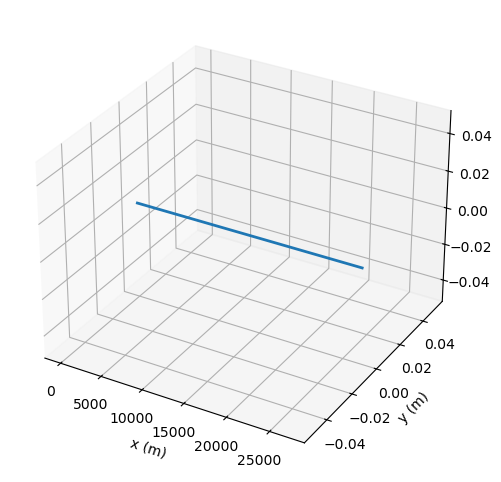

In [2]:
# Straight single tunnel geometry
L_tunnel = 27000      # tunnel length [m]
n_points = 270       # number of discretisation points
offset = 0       # use centreline, no lateral offset

TunX = np.linspace(0, L_tunnel, n_points)
TunY = offset * np.ones_like(TunX)
TunZ = np.zeros_like(TunX)

ax = plt.axes(projection='3d')
#ax.view_init(90, 270)

plt.plot(TunX, TunY, TunZ, lw=2)

plt.grid("on")
#ax.set_xlim(12000, 15000)
#plt.axis("equal")
plt.xlabel('x (m)')
plt.ylabel('y (m)')

## Properties of Beam

In [3]:
E = 40e9 #Pa 40GPa, take this as general value for Youngs modulus for C40/50 see appendix concrete hydraulic structures and offshore structures
G = 12e9 # https://eurocodeapplied.com/design/en1992/concrete-design-properties, shear modulus for this type of concrete

## Not a circle but an ellipse 
ao = 14 #m outer semi-major axis radius
ai = 13 #m inner semi-major axis radius
bo = 8.5 #m outer semi-minor axis radius
bi = 7.5 #m inner semi-minor axis radius

### Values of ellipse

In [4]:
# A0 = np.pi*(ao*bo), this was the area of the total ellipse
Atot = 104.6242421 #m2, including inner walls, calculated in excel

# Second moment of area for a hollow ellipse around the horizontal (major) axis
Ih = np.pi/4*(ao*bo**3 - ai*bi**3) # should be calcualted such that the inner walls are taken into account 

# Second moment of area for a hollow ellipse around the vertical (minor) axis
Iv = np.pi/4*(ao**3*bo - ai**3*bi)


print("Total Area Atot = ", Atot, "m2")
#print("Inner Area = ", np.pi*(ao*bo - ai*bi), "m2")
print("Ih = ", Ih, "m4")
print("Iv = ", Iv, "m4")

Total Area Atot =  104.6242421 m2
Ih =  2445.2390069675307 m4
Iv =  5377.22852570063 m4


In [5]:
Beam_m = 266.63                # [kg/m]
Beam_EIy = E*Ih   # bending about local y-axis, relevant for vertical z-deflection N.m2
Beam_EIz = E*Iv   # bending about local z-axis, relevant for horizontal y-deflection N.m2
Beam_EA = E * Atot                 # [N], wat do you take as A? also inner walls?
Beam_GJ = G * min(Iv, Ih)               # [N.m2]?
Beam_Im = 30                      #[kg.m]???

print("Beam bending stiffness around vertical minor axis, relevant for horizontal deflection EIv = ", Beam_EIy, "N.m2")
print("Beam bending stiffness around horizontal major axis, relevant for vertical deflection EIh = ", Beam_EIz, "N.m2")
print("Beam axial stiffness EA = ", Beam_EA, "N")
print("Beam torsional stiffness GJ = ", Beam_GJ, "N.m2")
print("Beam mass per unit length m = ", Beam_m, "kg/m")

Beam bending stiffness around vertical minor axis, relevant for horizontal deflection EIv =  97809560278701.23 N.m2
Beam bending stiffness around horizontal major axis, relevant for vertical deflection EIh =  215089141028025.2 N.m2
Beam axial stiffness EA =  4184969684000.0 N
Beam torsional stiffness GJ =  29342868083610.367 N.m2
Beam mass per unit length m =  266.63 kg/m


## Mesh setup

In [6]:
# Single tube tunnel mesh

L_tunnel = 27000       # tunnel length [m]
Le_target = 100        # target element length [m]

nEle_tunnel = int(round(L_tunnel / Le_target))
nNode = nEle_tunnel + 1

TunCX = np.linspace(0, L_tunnel, nNode)
TunCY = np.zeros(nNode)
TunCZ = np.zeros(nNode)

# Node coordinates
NodeC = [[x, y, z] for x, y, z in zip(TunCX, TunCY, TunCZ)]

# Tunnel beam elements
#        NodeLeft  NodeRight     m        EA        EIy       EIz       GJ        Im
Ele = [[i, i + 1, Beam_m, Beam_EA, Beam_EIy, Beam_EIz, Beam_GJ, Beam_Im]
       for i in range(nNode - 1)]

nEle = len(Ele)

print("Number of nodes    =", nNode)
print("Number of elements =", nEle)
print("Element length     =", L_tunnel / nEle, "m")

Number of nodes    = 271
Number of elements = 270
Element length     = 100.0 m


In [7]:
# # Single tube tunnel mesh -> connector elements not needed ?

# L_tunnel = 27000       # tunnel length [m]
# Le_target = 100         # target element length [m]

# nEle_tunnel = int(round(L_tunnel / Le_target))
nNode = nEle_tunnel + 1

# TunCX = np.linspace(0, L_tunnel, nNode)
# TunCY = np.zeros(nNode)
# TunCZ = np.zeros(nNode)

# # Node coordinates
# NodeC = [[x, y, z] for x, y, z in zip(TunCX, TunCY, TunCZ)]

# # Tunnel beam elements
# #        NodeLeft  NodeRight     m        EA        EI        GJ        Im
# Ele = [[i,        i + 1,      Beam_m, Beam_EA, Beam_EI, Beam_GJ, Beam_Im]
#        for i in range(nNode - 1)]

# nEle = len(Ele)

# print("Number of nodes    =", nNode)
# print("Number of elements =", nEle)
# print("Element length     =", L_tunnel / nEle, "m")

Nodes
0 	 0.0 	 0.0 	 0.0
1 	 100.0 	 0.0 	 0.0
2 	 200.0 	 0.0 	 0.0
3 	 300.0 	 0.0 	 0.0
4 	 400.0 	 0.0 	 0.0
5 	 500.0 	 0.0 	 0.0
6 	 600.0 	 0.0 	 0.0
7 	 700.0 	 0.0 	 0.0
8 	 800.0 	 0.0 	 0.0
9 	 900.0 	 0.0 	 0.0
10 	 1000.0 	 0.0 	 0.0
11 	 1100.0 	 0.0 	 0.0
12 	 1200.0 	 0.0 	 0.0
13 	 1300.0 	 0.0 	 0.0
14 	 1400.0 	 0.0 	 0.0
15 	 1500.0 	 0.0 	 0.0
16 	 1600.0 	 0.0 	 0.0
17 	 1700.0 	 0.0 	 0.0
18 	 1800.0 	 0.0 	 0.0
19 	 1900.0 	 0.0 	 0.0
20 	 2000.0 	 0.0 	 0.0
21 	 2100.0 	 0.0 	 0.0
22 	 2200.0 	 0.0 	 0.0
23 	 2300.0 	 0.0 	 0.0
24 	 2400.0 	 0.0 	 0.0
25 	 2500.0 	 0.0 	 0.0
26 	 2600.0 	 0.0 	 0.0
27 	 2700.0 	 0.0 	 0.0
28 	 2800.0 	 0.0 	 0.0
29 	 2900.0 	 0.0 	 0.0
30 	 3000.0 	 0.0 	 0.0
31 	 3100.0 	 0.0 	 0.0
32 	 3200.0 	 0.0 	 0.0
33 	 3300.0 	 0.0 	 0.0
34 	 3400.0 	 0.0 	 0.0
35 	 3500.0 	 0.0 	 0.0
36 	 3600.0 	 0.0 	 0.0
37 	 3700.0 	 0.0 	 0.0
38 	 3800.0 	 0.0 	 0.0
39 	 3900.0 	 0.0 	 0.0
40 	 4000.0 	 0.0 	 0.0
41 	 4100.0 	 0.0 	 0.0
42 	 420

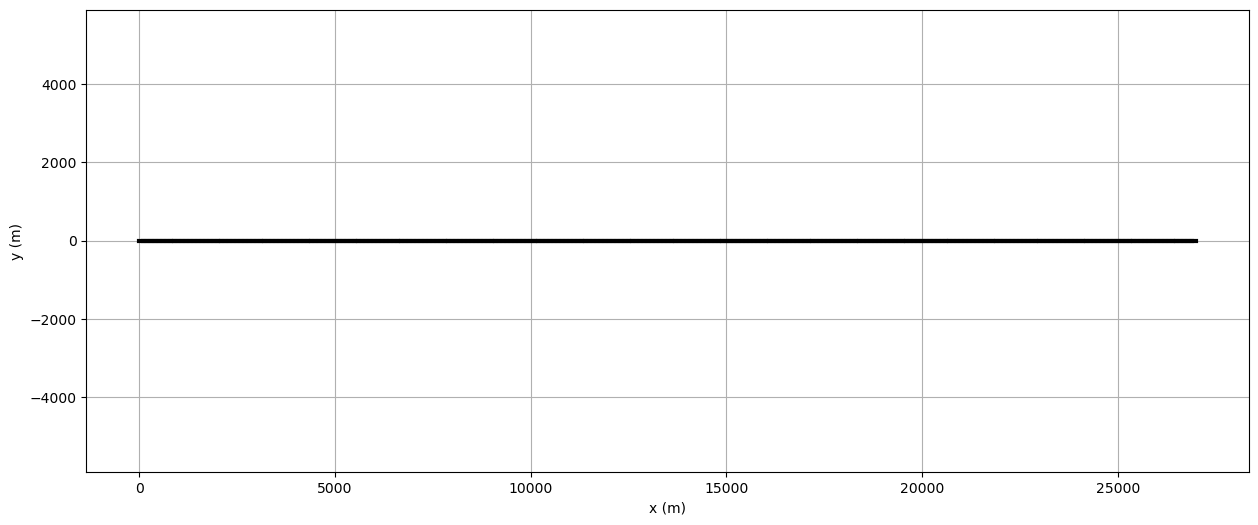

In [8]:
print("Nodes")
for iNode in range(0, nNode):
    print(iNode, "\t", NodeC[iNode][0], "\t", NodeC[iNode][1], "\t", NodeC[iNode][2])

plt.figure()
print("Elements")
for iEle in range(0, nEle):
    n1, n2, m, EA, EIy, EIz, GJ, Im = Ele[iEle]
    n1 = int(round(n1))
    n2 = int(round(n2))
    #print(iEle, n1, n2, m, EA, EIy, EIz, GJ, Im)    
    plt.plot( [NodeC[n1][0], NodeC[n2][0]], 
             [NodeC[n1][1], NodeC[n2][1]],              
             lw=3, color='k')

plt.grid("on")
plt.axis("equal")
plt.xlabel('x (m)')
plt.ylabel('y (m)')
pass

## Define the shape functions

Here we will use **linear** shape functions for the **axial displacement** and **cubic** shape functions for the **deflection and rotations**. Since we already know its expression and we already have the value of the elemental matrices, we skip this step in this tutorial. 

## Computation of the elemental matrices

In the theory we have seen that the mass and stiffness elemental matrices for the space frame using linear and cubic shape functions are given by:

| <img width="50%" src="./img/nb09_f01_3Ddofs_nptel.png" /> |
| :---- |
| Fig 1: Definition of 3 dofs per node, for the 2 noded elements. (This is from my lectures slides. To Be replaced) |

$$ M = \frac{mL}{420} 
\begin{bmatrix} 
140 & 0 & 0 & 0 & 0 & 0 & 70 & 0 & 0 & 0 & 0 & 0 \\ 
0 & 156 & 0 & 0 & 0 & 22L & 0 & 54 & 0 & 0 & 0 & -13L \\ 
0 & 0 & 156 & 0 & 22L & 0 & 0 & 0 & 54 & 0 & 13L & 0 \\ 
0 & 0 & 0 & 140 & 0 & 0 & 0 & 0 & 0 & 70 & 0 & 0 \\ 
0 & 0 & 22L & 0 & 4L^2 & 0 & 0 & 0 & -13L & 0 & -3L^2 & 0 \\ 
0 & 22L & 0 & 0 & 0 & 4L^2 & 0 & 13L & 0 & 0 & 0 & -3L^2 \\ 
70 & 0 & 0 & 0 & 0 & 0 & 140 & 0 & 0 & 0 & 0 & 0 \\ 
0 & 54 & 0 & 0 & 0 & 13L & 0 & 156 & 0 & 0 & 0 & -22L \\ 
0 & 0 & 54 & 0 & -13L & 0 & 0 & 0 & 156 & 0 & 22L & 0 \\ 
0 & 0 & 0 & 70 & 0 & 0 & 0 & 0 & 0 & 140 & 0 & 0 \\ 
0 & 0 & 13L & 0 & -3L^2 & 0 & 0 & 0 & 22L & 0 & 4L^2 & 0 \\
0 & -13L & 0 & 0 & 0 & -3L^2 & 0 & -22L & 0 & 0 & 0 & 4L^2
\end{bmatrix} $$
$$ \quad K = 
\begin{bmatrix} 
\frac{EA}{L} & 0 & 0 & 0 & 0 & 0 & \frac{-EA}{L} &  0 & 0 & 0 & 0 & 0\\ 
0 & \frac{12EI}{L^3} & 0 & 0 & 0 & \frac{6EI}{L^2} & 0 & \frac{-12EI}{L^3} & 0 & 0 & 0 & \frac{6EI}{L^2} \\ 
0 & 0 & \frac{12EI}{L^3} & 0 & -\frac{6EI}{L^2} & 0 & 0 & 0 & \frac{-12EI}{L^3} & 0 & -\frac{6EI}{L^2} & 0\\ 
0 & 0 & 0 & \frac{GJ}{L} & 0 & 0 & 0 & 0 & 0 & -\frac{GJ}{L} & 0 & 0 \\ 
0 & 0 & \frac{-6EI}{L^2} & 0 & \frac{4EI}{L} & 0 & 0 & 0 & \frac{6EI}{L^2} & 0 & \frac{2EI}{L} & 0 \\ 
0 & \frac{6EI}{L^2} & 0 & 0 & 0 & \frac{4EI}{L} & 0 & \frac{-6EI}{L^2} & 0 & 0 & 0 & \frac{2EI}{L} \\ 
\frac{-EA}{L} & 0 & 0 & 0 & 0 & 0 & \frac{EA}{L} & 0 & 0 & 0 & 0 & 0 \\ 
0 & -\frac{12EI}{L^3} & 0 & 0 & 0 & -\frac{6EI}{L^2} & 0 & \frac{12EI}{L^3} & 0 & 0 & 0 & -\frac{6EI}{L^2} \\ 
0 & 0 & -\frac{12EI}{L^3} & 0 & \frac{6EI}{L^2} & 0 & 0 & 0 & \frac{12EI}{L^3} & 0 & \frac{6EI}{L^2} & 0\\ 
0 & 0 & 0 & -\frac{GJ}{L} & 0 & 0 & 0 & 0 & 0 & \frac{GJ}{L} & 0 & 0 \\ 
0 & 0 & -\frac{6EI}{L^2} & 0 & \frac{2EI}{L} & 0 & 0 & 0 & \frac{6EI}{L^2} & 0 & \frac{4EI}{L} & 0 \\ 
0 & \frac{6EI}{L^2} & 0 & 0 & 0 & \frac{2EI}{L} & 0 & -\frac{6EI}{L^2} & 0 & 0 & 0 & \frac{4EI}{L}
\end{bmatrix}$$

These matrices are used directly when calling the `BeamMatrices` function within the assembly process.

## Global assembly

The last step is to compute the global matrices and the global forcing vector. We start by initializing the global matrices as 1-dimensional arrays.

Then we loop over elements and perform all the elemental operations.

In [9]:
from BeamMatrices import Beam3DMatrices
LDOF = 6
nDof = LDOF * nNode  # 6 dof per node

K = np.zeros((nDof, nDof))
M = np.zeros((nDof, nDof))
Q = np.zeros((nDof, nDof))

exeTime = [0.0, 0.0]
exeTime[0] = time.time()

for iEle in range(nEle):

    n1, n2, m, EA, EIy, EIz, GJ, Im = Ele[iEle]

    n1 = int(round(n1))
    n2 = int(round(n2))

    n1dof = LDOF * n1 + np.arange(LDOF)
    n2dof = LDOF * n2 + np.arange(LDOF)

    # Element matrices
    Me, Ke, Qe = Beam3DMatrices(
        m, EA, EIy, EIz, GJ, Im,
        [NodeC[n1], NodeC[n2]]
    )

    indexes = np.append(n1dof, n2dof)

    for i in range(2 * LDOF):
        for j in range(2 * LDOF):
            M[indexes[i], indexes[j]] += Me[i, j]
            K[indexes[i], indexes[j]] += Ke[i, j]
            Q[indexes[i], indexes[j]] += Qe[i, j]

exeTime[1] = time.time()
print("Execution time = ", exeTime[1] - exeTime[0], "s")

Execution time =  0.12105941772460938 s


In [10]:
# LDOF = 6
# nDof = LDOF*nNode  #6 dof per node
# K = np.zeros(nDof*nDof)
# M = np.zeros(nDof*nDof)
# Q = np.zeros(nDof*nDof)

# from BeamMatrices import Beam3DMatrices

# exeTime = [0.0, 0.0]
# exeTime[0] = time.time()

# for iEle in range(0, nEle):
#     n1, n2, m, EA, EIy, EIz, GJ, Im = Ele[iEle]
#     n1 = int(round(n1))
#     n2 = int(round(n2))
    
#     n1dof = LDOF*n1 + np.arange(0,LDOF)
#     n2dof = LDOF*n2 + np.arange(0,LDOF)    
    
#     # Calculate elemental matrices
#     Me, Ke, Qe = Beam3DMatrices(
#     m, EA, EIy, EIz, GJ, Im,
#     [NodeC[n1], NodeC[n2]])
    
#     indexes = np.append(n1dof, n2dof)
#     for i in range(0, 2*LDOF):
#         for j in range(0, 2*LDOF):
#             ij = indexes[i]*nDof + indexes[j]
#             #print(ij)
#             M[ij] = M[ij] + Me[i,j]
#             K[ij] = K[ij] + Ke[i,j]
#             Q[ij] = Q[ij] + Qe[i,j] # load at each dof, multiply Q by a vector f 

# # Reshape the global matrix from a 1-dimensional array to a 2-dimensional array
# M = M.reshape((nDof, nDof))
# K = K.reshape((nDof, nDof))
# Q = Q.reshape((nDof, nDof))

# exeTime[1] = time.time()
# print("Execution time = ", exeTime[1] - exeTime[0], "s")

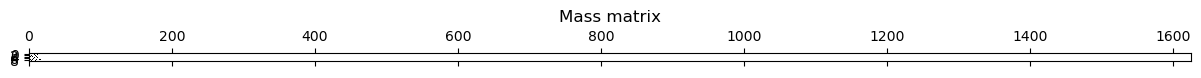

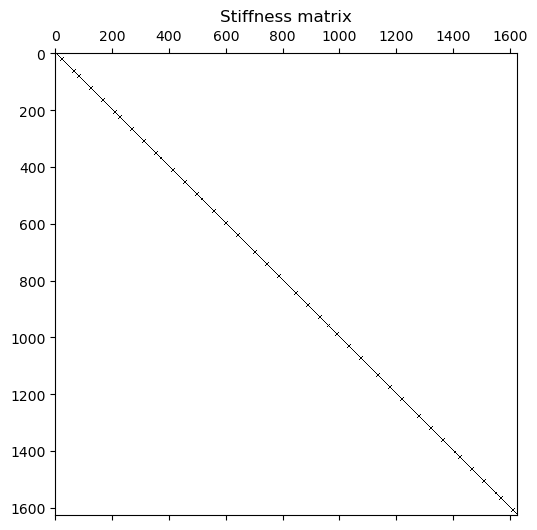

In [11]:
# Look at the matrix structure
plt.figure()
plt.spy(M[:10])
plt.title("Mass matrix")
plt.figure()
plt.spy(K)
plt.title("Stiffness matrix")
pass

## Boundary conditions

To apply the boundary conditions, we will remove the rows associated to the fixed DOFs and add the contribution to the right-hand-side. First, we obtain the free and fixed DOFs.

[   0    1    2    3    4    5  804  805  806  807  808  809  816  817
  818  819  820  821 1620 1621 1622 1623 1624 1625]
[   6    7    8 ... 1617 1618 1619]


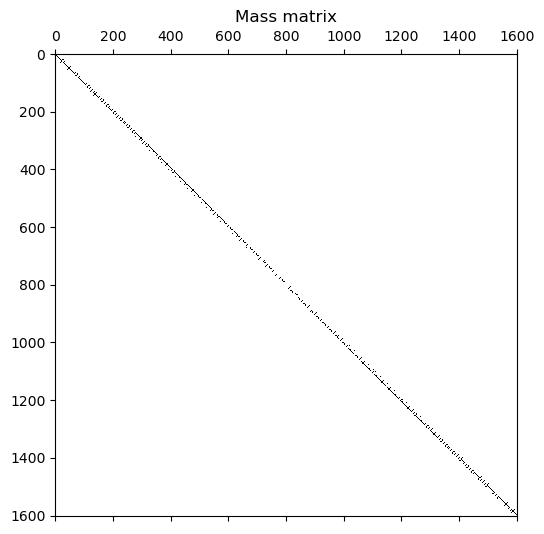

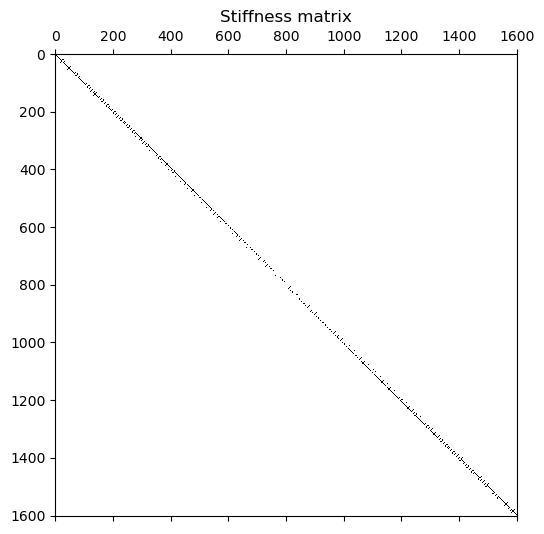

In [12]:
NodesClamp = (0, int(round(nNode/2-1)), int(round(nNode/2)), nNode-1)

# Prescribed dofs
DofsP = np.empty([0], dtype=int)
for n0 in NodesClamp:
    DofsP = np.append(DofsP, n0*LDOF + np.arange(0,LDOF))

# Free dofs
DofsF = np.arange(0, nDof)       # free DOFs
DofsF = np.delete(DofsF, DofsP)  # remove the fixed DOFs from the free DOFs array

print(DofsP)
print(DofsF)

M_FF = [ M[iRow,DofsF].tolist() for iRow in DofsF ]
K_FF = [ K[iRow,DofsF].tolist() for iRow in DofsF ]
Q_FF = [ Q[iRow,DofsF].tolist() for iRow in DofsF ]

plt.figure()
plt.spy(M_FF)
plt.title("Mass matrix")
plt.figure()
plt.spy(K_FF)
plt.title("Stiffness matrix")
pass

## Modal analysis

Using the matrices associated to the free DOFs, we can perform a modal analysis to get more information on how the structure will deform and determine the natural frequencies.

$$ ( K_{FF} - \omega^2 M_{FF} ) \phi = 0 $$

To compute the natural frequencies and mode shapes we use the `eig` command, which is part of the NumPy package. For more information see: https://numpy.org/doc/stable/reference/generated/numpy.linalg.eig.html

In [13]:
mat = np.dot(np.linalg.inv(M_FF), K_FF)
w2, vr = np.linalg.eig(mat)
w = np.sqrt(w2.real)
f = w/2/np.pi
print(len(f))

1602


C:\Users\arthu\AppData\Local\Temp\ipykernel_19580\367166604.py:3: RuntimeWarning: invalid value encountered in sqrt
  w = np.sqrt(w2.real)


In [14]:
idx = f.argsort()
f = f[idx]
vr = vr[:,idx]

print(f)

[0.01201092 0.01201092 0.01781128 ...        nan        nan        nan]


In [15]:
nMode = len(f)
print(nMode)
ModalShape = np.zeros((nDof, nMode))
ModalShape[DofsF,:] = vr

1602


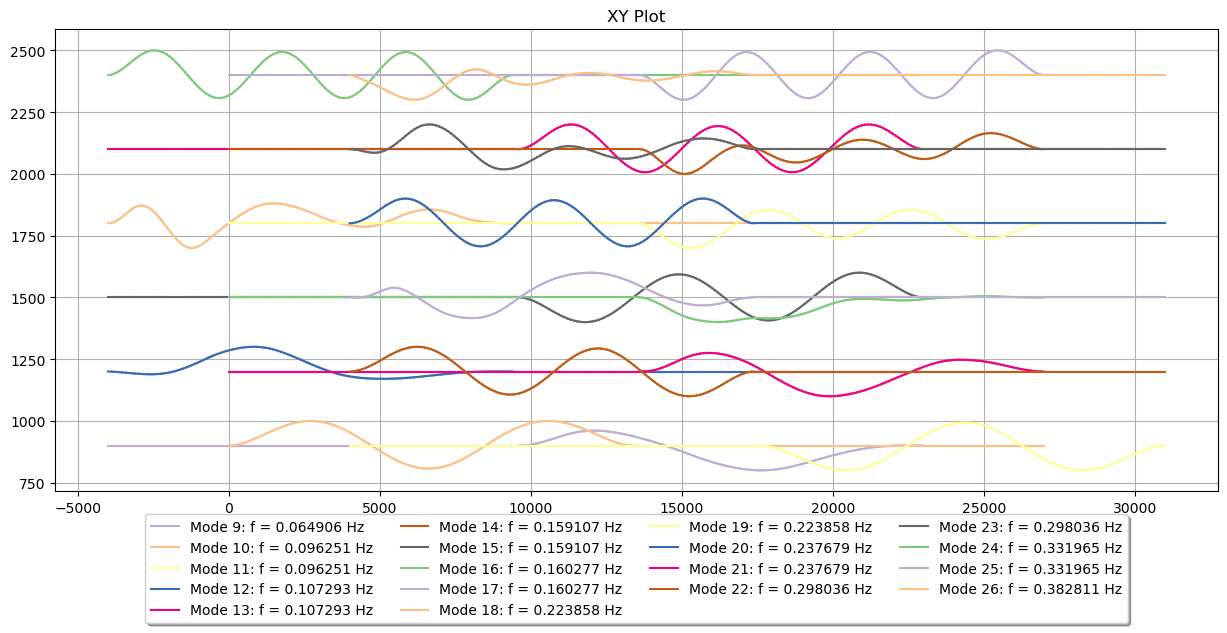

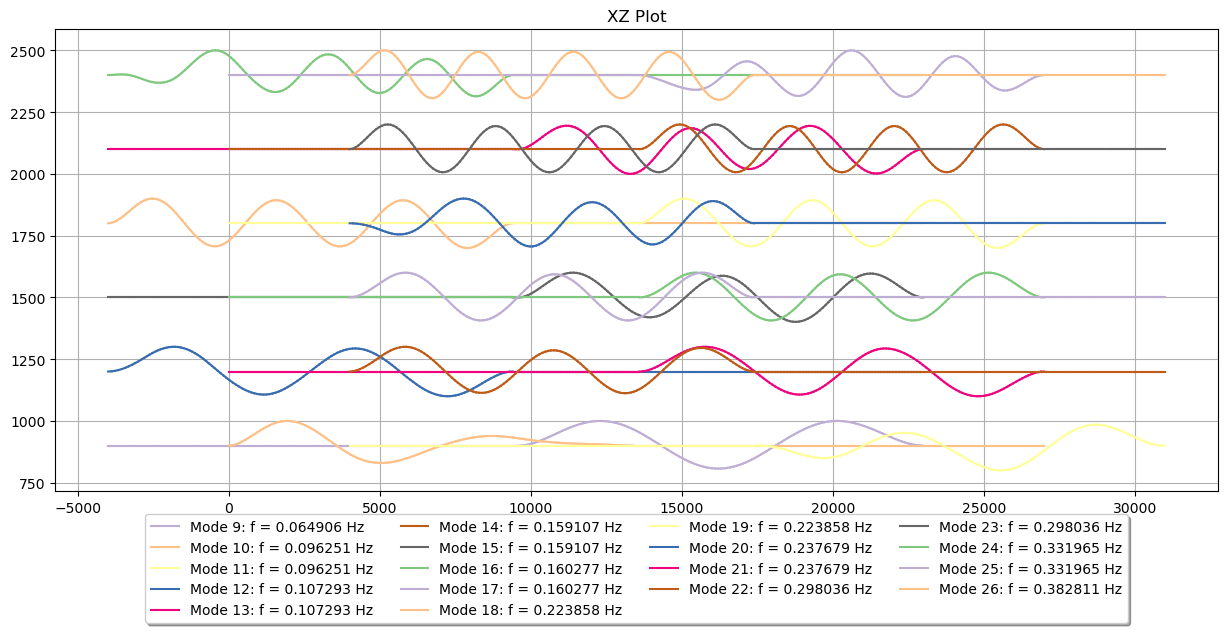

In [16]:
# Plotting mode shapes
plt.figure()
cmap = plt.colormaps.get_cmap('Accent')
cmap = cmap.colors
nCmap = len(cmap)

nCol = 2
nRow = int(np.floor(nMode/nCol))+1

vMode1 = 9
vMode2 = vMode1+18

def plotEle(DisplacedNode):
    for iElem in np.arange(0, nEle):
        NodeLeft = int(round(Ele[iElem][0]))
        NodeRight = int(round(Ele[iElem][1]))
        if(iElem == 0):
            plt.plot([DisplacedNode[0][NodeLeft], DisplacedNode[0][NodeRight]], 
                     [DisplacedNode[1][NodeLeft], DisplacedNode[1][NodeRight]], color=cmap[iMode%nCmap], 
                     label = "Mode "+str(iMode)+": f = "+str(np.round(f[iMode],6))+" Hz")
        else:
            plt.plot([DisplacedNode[0][NodeLeft], DisplacedNode[0][NodeRight]], 
                     [DisplacedNode[1][NodeLeft], DisplacedNode[1][NodeRight]], color=cmap[iMode%nCmap])


# XY Plot
for iMode in np.arange(vMode1, vMode2):    
    Shape = ModalShape[:, iMode]

    # Scale the mode such that maximum deformation is 10
    MaxTranslationx = np.max(np.abs(Shape[0::LDOF]))
    MaxTranslationy = np.max(np.abs(Shape[1::LDOF]))
    MaxTranslationz = np.max(np.abs(Shape[2::LDOF]))
    Shape[0::LDOF] = Shape[0::LDOF]/MaxTranslationx*100
    Shape[1::LDOF] = Shape[1::LDOF]/MaxTranslationy*100
    Shape[2::LDOF] = Shape[2::LDOF]/MaxTranslationz*100    

    # Get the deformed shape
    DisplacedNode = ([i[0] + (iMode%3-1)*4000 for i in NodeC] + Shape[0::LDOF], 
                     [i[1] + 300*np.floor(iMode/3) for i in NodeC] + Shape[1::LDOF])
    
    plotEle(DisplacedNode)
    plt.title("XY Plot")        
    plt.grid('on')
    plt.legend(loc='lower center', bbox_to_anchor=(0.5, -0.3),
          ncol=4, fancybox=True, shadow=True)    


# XZ Plot
plt.figure()
for iMode in np.arange(vMode1, vMode2):    
    Shape = ModalShape[:, iMode]

    # Scale the mode such that maximum deformation is 10
    MaxTranslationx = np.max(np.abs(Shape[0::LDOF]))
    MaxTranslationy = np.max(np.abs(Shape[1::LDOF]))
    MaxTranslationz = np.max(np.abs(Shape[2::LDOF]))
    Shape[0::LDOF] = Shape[0::LDOF]/MaxTranslationx*100
    Shape[1::LDOF] = Shape[1::LDOF]/MaxTranslationy*100
    Shape[2::LDOF] = Shape[2::LDOF]/MaxTranslationz*100

    # Get the deformed shape
    DisplacedNode = ([i[0] + (iMode%3-1)*4000 for i in NodeC] + Shape[0::LDOF],
                     [i[2] + np.floor(iMode/3)*300 for i in NodeC] + Shape[2::LDOF])
    
    plotEle(DisplacedNode)
    plt.title("XZ Plot")    
    plt.grid('on')
    plt.legend(loc='lower center', bbox_to_anchor=(0.5, -0.3),
          ncol=4, fancybox=True, shadow=True)    
    


pass